# C2ST: Can a discriminator tell generated halos from real ones?

**Classifier two-sample test (C2ST).** We train a CNN to label every halo cutout as either *true* (from `truth_maps`) or *generated* (from the flow-matching model). The model wins if the classifier ends up at ~50% accuracy: indistinguishable.

Run under test: `fm_two_head`.

**Data**: all halos from 1P + CV + SB35 (`Test/`) suites are pooled into one big set, then randomly split at the halo level: 70% train / 10% val / 20% test.

Both a **joint** (3-channel) classifier and three **per-channel** classifiers (DM_hydro / Gas / Stars) are trained. Per-channel is diagnostic — stars is likely the easiest to spot, DM_hydro the hardest.

In [1]:
from __future__ import annotations
import os, json, glob, math, random
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, ConcatDataset
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', DEVICE)
torch.backends.cudnn.benchmark = True

SEED = 0
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device: cuda


In [2]:
# --- configuration ---
TESTSUITE_ROOT = Path('/mnt/home/mlee1/ceph/fm_testsuite')
RUN_NAME       = 'fm_two_head'
SNAP           = 'snap_090'
MASS_DIR       = 'mass_threshold_1p000e13'
CHANNEL_NAMES  = ['DM_hydro', 'Gas', 'Stars']
BOX_MPC        = 50.0     # CAMELS L50 box
PATCH_PIX      = 128      # cutout size, same as model output
ALL_SUITES     = ['1P', 'CV', 'Test']   # pool halos from all three

TEST_FRAC = 0.20
VAL_FRAC  = 0.10

# log-space normalization for stable training (independent of model norm stats)
# log10(x+1) collapses physical-space hydro mass density to ~O(1) range.
def preprocess(x):
    """x: (..., 3, H, W) physical-space hydro mass density. Returns log10(x+1)."""
    return np.log10(np.maximum(x, 0.0) + 1.0).astype(np.float32)

In [3]:
# --- discover sims across all suites ---
def discover_sims(suite):
    sims = []
    for sim_dir in sorted((TESTSUITE_ROOT / suite).iterdir()):
        if not sim_dir.is_dir():
            continue
        gen_path  = sim_dir / SNAP / MASS_DIR / RUN_NAME / 'generated_halos.npz'
        cat_path  = sim_dir / SNAP / MASS_DIR / 'halo_catalog.npz'
        full_path = sim_dir / SNAP / 'full_maps.npz'
        if gen_path.exists() and cat_path.exists() and full_path.exists():
            sims.append({'suite': suite, 'sim_id': sim_dir.name,
                         'gen': gen_path, 'cat': cat_path, 'full': full_path})
    return sims

all_sims = [s for suite in ALL_SUITES for s in discover_sims(suite)]
print(f'{len(all_sims)} sims total across {ALL_SUITES}')
for suite in ALL_SUITES:
    print(f'  {suite}: {sum(1 for s in all_sims if s["suite"] == suite)}')

268 sims total across ['1P', 'CV', 'Test']
  1P: 139
  CV: 27
  Test: 102


In [4]:
# --- extract true halo cutouts the same way the test pipeline does ---
def periodic_cutout(field, cx, cy, size):
    """field: (..., N, N); returns (..., size, size) with periodic wrap."""
    n = field.shape[-1]
    half = size // 2
    ix = (cx - half + np.arange(size)) % n
    iy = (cy - half + np.arange(size)) % n
    return field[..., ix[:, None], iy[None, :]]

def load_sim_pairs(sim):
    """Return (true_cuts, gen_cuts) both shape (N, 3, 128, 128) in log space."""
    cat  = np.load(sim['cat'])
    full = np.load(sim['full'])
    gen  = np.load(sim['gen'])['generated']        # (N, 3, 128, 128) physical
    truth = full['truth_maps']                      # (3, 1024, 1024) physical
    centers_mpc = cat['centers']                    # (N, 2) Mpc/h

    npix = truth.shape[-1]
    pix_per_mpc = npix / BOX_MPC
    n_halos = centers_mpc.shape[0]
    if gen.shape[0] != n_halos:
        n_halos = min(gen.shape[0], n_halos)
    true_cuts = np.zeros((n_halos, 3, PATCH_PIX, PATCH_PIX), dtype=np.float32)
    for i in range(n_halos):
        cx = int(centers_mpc[i, 0] * pix_per_mpc) % npix
        cy = int(centers_mpc[i, 1] * pix_per_mpc) % npix
        true_cuts[i] = periodic_cutout(truth, cx, cy, PATCH_PIX)
    return preprocess(true_cuts), preprocess(gen[:n_halos])

# quick sanity check on one sim
t0, g0 = load_sim_pairs(all_sims[0])
print(all_sims[0]['suite'], all_sims[0]['sim_id'], '  true', t0.shape, '  gen', g0.shape)
print('true range:', t0.min(), t0.max(), '   gen range:', g0.min(), g0.max())

1P 1P_p10_1   true (49, 3, 128, 128)   gen (49, 3, 128, 128)
true range: 0.0 12.394961    gen range: 0.0 12.4290285


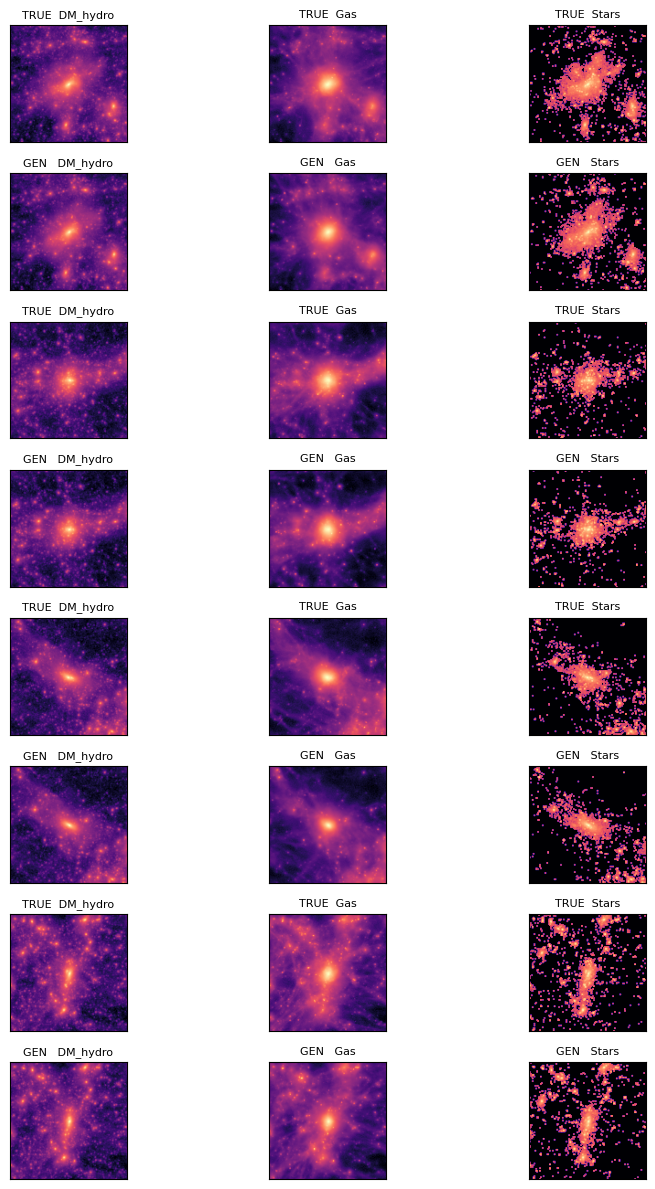

In [5]:
# --- visual sanity check: true vs generated for a few halos ---
n_show = 4
fig, axes = plt.subplots(2 * n_show, 3, figsize=(9, 3 * n_show))
for row in range(n_show):
    for ch in range(3):
        axes[2 * row,     ch].imshow(t0[row, ch], cmap='magma')
        axes[2 * row + 1, ch].imshow(g0[row, ch], cmap='magma')
        axes[2 * row,     ch].set_title(f'TRUE  {CHANNEL_NAMES[ch]}', fontsize=8)
        axes[2 * row + 1, ch].set_title(f'GEN   {CHANNEL_NAMES[ch]}', fontsize=8)
        for ax in (axes[2 * row, ch], axes[2 * row + 1, ch]):
            ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

In [7]:
# --- load every halo from every sim, then split randomly at the halo level ---
def materialize_all(sims):
    trues, gens = [], []
    skipped = 0
    for s in tqdm(sims, desc='loading'):
        t, g = load_sim_pairs(s)
        if t.shape[0] == 0 or t.shape[1:] != (3, PATCH_PIX, PATCH_PIX):
            skipped += 1
            continue
        trues.append(t); gens.append(g)
    if skipped:
        print(f'  skipped {skipped} sims with 0 halos or unexpected shape')
    return np.concatenate(trues, 0), np.concatenate(gens, 0)

X_true_all, X_gen_all = materialize_all(all_sims)
n_halos = X_true_all.shape[0]
assert X_gen_all.shape[0] == n_halos
print(f'pooled halos: {n_halos}  (true and generated paired 1:1)')

rng = np.random.default_rng(SEED)
perm = rng.permutation(n_halos)
n_test  = int(TEST_FRAC * n_halos)
n_val   = int(VAL_FRAC  * n_halos)
test_idx  = perm[:n_test]
val_idx   = perm[n_test:n_test + n_val]
train_idx = perm[n_test + n_val:]

X_tr_true, X_tr_gen = X_true_all[train_idx], X_gen_all[train_idx]
X_va_true, X_va_gen = X_true_all[val_idx],   X_gen_all[val_idx]
X_te_true, X_te_gen = X_true_all[test_idx],  X_gen_all[test_idx]
print(f'train halos: {len(train_idx)}   val: {len(val_idx)}   test: {len(test_idx)}')


loading:   0%|          | 0/268 [00:00<?, ?it/s]

  skipped 1 sims with 0 halos or unexpected shape
pooled halos: 12249  (true and generated paired 1:1)
train halos: 8576   val: 1224   test: 2449


In [8]:
# --- standardize all splits with stats from the TRUE training halos ---
# Using the same mu/std on both classes prevents the classifier from cheating
# on a global brightness offset that might differ between true and generated.
mu  = X_tr_true.mean(axis=(0, 2, 3), keepdims=True)
std = X_tr_true.std (axis=(0, 2, 3), keepdims=True) + 1e-6
print('per-channel mu:',  mu.ravel())
print('per-channel std:', std.ravel())

def standardize(x):
    return (x - mu) / std

X_tr_true = standardize(X_tr_true); X_tr_gen = standardize(X_tr_gen)
X_va_true = standardize(X_va_true); X_va_gen = standardize(X_va_gen)
X_te_true = standardize(X_te_true); X_te_gen = standardize(X_te_gen)

# free the unstandardized copies
del X_true_all, X_gen_all

per-channel mu: [9.899266  9.245689  1.5128281]
per-channel std: [0.45178366 0.39120007 2.9298856 ]


In [9]:
# --- dataset & dataloader ---
class HaloPairs(Dataset):
    """Yields (image, label) where label=1 for true and 0 for generated.
    Selecting channels=None gives all 3; channels=[c] gives a single channel."""
    def __init__(self, true_arr, gen_arr, channels=None, augment=False):
        self.true = true_arr; self.gen = gen_arr
        self.channels = channels
        self.augment = augment
        self.n = true_arr.shape[0] + gen_arr.shape[0]

    def __len__(self):
        return self.n

    def __getitem__(self, idx):
        if idx < self.true.shape[0]:
            x = self.true[idx]; y = 1.0
        else:
            x = self.gen[idx - self.true.shape[0]]; y = 0.0
        if self.channels is not None:
            x = x[self.channels]
        if self.augment:
            # random 90-degree rotation + random flips (hydro fields are rotation/flip invariant)
            k = random.randint(0, 3)
            if k: x = np.rot90(x, k, axes=(-2, -1)).copy()
            if random.random() < 0.5: x = x[..., ::-1, :].copy()
            if random.random() < 0.5: x = x[..., :, ::-1].copy()
        return torch.from_numpy(x), torch.tensor(y, dtype=torch.float32)

In [10]:
# --- small CNN classifier ---
class HaloDiscriminator(nn.Module):
    def __init__(self, in_ch=3, base=32):
        super().__init__()
        def block(ic, oc):
            return nn.Sequential(
                nn.Conv2d(ic, oc, 3, stride=2, padding=1),
                nn.GroupNorm(8, oc),
                nn.SiLU(),
            )
        self.net = nn.Sequential(
            block(in_ch, base),      # 128 -> 64
            block(base, base * 2),   # 64 -> 32
            block(base * 2, base * 4),  # 32 -> 16
            block(base * 4, base * 8),  # 16 -> 8
            block(base * 8, base * 8),  # 8 -> 4
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(base * 8, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

In [11]:
# --- training loop ---
def train_classifier(channels, tag, epochs=20, lr=2e-4, batch_size=64):
    in_ch = 3 if channels is None else len(channels)
    model = HaloDiscriminator(in_ch=in_ch).to(DEVICE)
    opt   = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    bce   = nn.BCEWithLogitsLoss()

    train_ds = HaloPairs(X_tr_true, X_tr_gen, channels=channels, augment=True)
    val_ds   = HaloPairs(X_va_true, X_va_gen, channels=channels, augment=False)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=0, drop_last=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=0)

    best_val_acc = 0.0
    best_state = None
    history = []

    for ep in range(epochs):
        model.train()
        for x, y in train_loader:
            x = x.to(DEVICE, non_blocking=True); y = y.to(DEVICE, non_blocking=True)
            opt.zero_grad()
            logits = model(x)
            loss = bce(logits, y)
            loss.backward(); opt.step()
        sched.step()

        # validation
        model.eval()
        all_logits, all_y = [], []
        with torch.no_grad():
            for x, y in val_loader:
                x = x.to(DEVICE); all_logits.append(model(x).cpu()); all_y.append(y)
        logits = torch.cat(all_logits); ys = torch.cat(all_y)
        preds = (torch.sigmoid(logits) > 0.5).float()
        val_acc = (preds == ys).float().mean().item()
        history.append((ep, loss.item(), val_acc))
        print(f'[{tag}] ep {ep:02d}  train_loss={loss.item():.4f}  val_acc={val_acc:.4f}')
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    return model, history, best_val_acc

In [12]:
# --- evaluation on held-out test sims ---
def evaluate(model, channels, tag):
    ds = HaloPairs(X_te_true, X_te_gen, channels=channels, augment=False)
    loader = DataLoader(ds, batch_size=128, shuffle=False, num_workers=0)
    model.eval()
    all_logits, all_y = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE)
            all_logits.append(model(x).cpu()); all_y.append(y)
    logits = torch.cat(all_logits).numpy(); ys = torch.cat(all_y).numpy()
    probs  = 1.0 / (1.0 + np.exp(-logits))
    preds  = (probs > 0.5).astype(np.float32)
    acc    = float((preds == ys).mean())
    # AUROC by ranking
    order = np.argsort(-probs)
    y_sorted = ys[order]
    n_pos = ys.sum(); n_neg = len(ys) - n_pos
    tp = np.cumsum(y_sorted); fp = np.cumsum(1 - y_sorted)
    tpr = tp / max(n_pos, 1); fpr = fp / max(n_neg, 1)
    auroc = float(np.trapz(tpr, fpr))
    # fraction of generated halos that fooled the classifier (predicted true)
    gen_mask = (ys == 0)
    fool_rate = float((probs[gen_mask] > 0.5).mean())
    return {'tag': tag, 'test_acc': acc, 'auroc': auroc, 'fool_rate': fool_rate,
            'probs': probs, 'ys': ys}

In [13]:
# --- train joint classifier (all 3 channels) ---
joint_model, joint_hist, joint_best_val = train_classifier(channels=None, tag='joint', epochs=20)
joint_result = evaluate(joint_model, channels=None, tag='joint')
print(joint_result['tag'], '  test acc:', joint_result['test_acc'],
      '  AUROC:', joint_result['auroc'], '  fool rate:', joint_result['fool_rate'])

[joint] ep 00  train_loss=0.6974  val_acc=0.5527
[joint] ep 01  train_loss=0.6271  val_acc=0.6381
[joint] ep 02  train_loss=0.5693  val_acc=0.6377
[joint] ep 03  train_loss=0.5786  val_acc=0.6949
[joint] ep 04  train_loss=0.5236  val_acc=0.7002
[joint] ep 05  train_loss=0.5431  val_acc=0.7251
[joint] ep 06  train_loss=0.4809  val_acc=0.7353
[joint] ep 07  train_loss=0.5714  val_acc=0.7410
[joint] ep 08  train_loss=0.3594  val_acc=0.7463
[joint] ep 09  train_loss=0.4985  val_acc=0.7418
[joint] ep 10  train_loss=0.4047  val_acc=0.7484
[joint] ep 11  train_loss=0.4518  val_acc=0.7549
[joint] ep 12  train_loss=0.2953  val_acc=0.7627
[joint] ep 13  train_loss=0.3307  val_acc=0.7700
[joint] ep 14  train_loss=0.3484  val_acc=0.7700
[joint] ep 15  train_loss=0.3700  val_acc=0.7704
[joint] ep 16  train_loss=0.3054  val_acc=0.7700
[joint] ep 17  train_loss=0.3997  val_acc=0.7721
[joint] ep 18  train_loss=0.2954  val_acc=0.7733
[joint] ep 19  train_loss=0.5017  val_acc=0.7745
joint   test acc: 0.

In [14]:
# --- train one classifier per channel ---
per_channel_results = []
per_channel_models  = {}
for ch_idx, name in enumerate(CHANNEL_NAMES):
    model, hist, best_val = train_classifier(channels=[ch_idx], tag=name, epochs=20)
    res = evaluate(model, channels=[ch_idx], tag=name)
    per_channel_results.append(res)
    per_channel_models[name] = model
    print(f'[{name}] test acc={res["test_acc"]:.4f}  AUROC={res["auroc"]:.4f}  fool_rate={res["fool_rate"]:.4f}')

[DM_hydro] ep 00  train_loss=0.6962  val_acc=0.4992
[DM_hydro] ep 01  train_loss=0.6921  val_acc=0.5261
[DM_hydro] ep 02  train_loss=0.6912  val_acc=0.5862
[DM_hydro] ep 03  train_loss=0.7088  val_acc=0.5907
[DM_hydro] ep 04  train_loss=0.5959  val_acc=0.6777
[DM_hydro] ep 05  train_loss=0.4875  val_acc=0.6957
[DM_hydro] ep 06  train_loss=0.5098  val_acc=0.7112
[DM_hydro] ep 07  train_loss=0.4996  val_acc=0.7218
[DM_hydro] ep 08  train_loss=0.3177  val_acc=0.7402
[DM_hydro] ep 09  train_loss=0.4199  val_acc=0.7480
[DM_hydro] ep 10  train_loss=0.3481  val_acc=0.7410
[DM_hydro] ep 11  train_loss=0.4241  val_acc=0.7475
[DM_hydro] ep 12  train_loss=0.3600  val_acc=0.7463
[DM_hydro] ep 13  train_loss=0.4156  val_acc=0.7475
[DM_hydro] ep 14  train_loss=0.3932  val_acc=0.7496
[DM_hydro] ep 15  train_loss=0.2632  val_acc=0.7455
[DM_hydro] ep 16  train_loss=0.3353  val_acc=0.7418
[DM_hydro] ep 17  train_loss=0.3240  val_acc=0.7484
[DM_hydro] ep 18  train_loss=0.3108  val_acc=0.7504
[DM_hydro] e

In [15]:
# --- verdict table ---
results = [joint_result] + per_channel_results
print(f'{"setup":>12}  {"test_acc":>8}  {"AUROC":>6}  {"fool_rate":>9}   verdict')
for r in results:
    verdict = ('FOOLED — indistinguishable' if r['test_acc'] < 0.55
               else ('partial' if r['test_acc'] < 0.70 else 'CAUGHT'))
    print(f'{r["tag"]:>12}  {r["test_acc"]:8.4f}  {r["auroc"]:6.3f}  {r["fool_rate"]:9.3f}   {verdict}')
print('\nA classifier accuracy near 0.5 means the model fools the discriminator.')
print('AUROC near 0.5 = no rank-ordering signal. fool_rate is the fraction of generated halos that scored as true.')

       setup  test_acc   AUROC  fool_rate   verdict
       joint    0.7789   0.884      0.218   CAUGHT
    DM_hydro    0.7587   0.870      0.214   CAUGHT
         Gas    0.7971   0.882      0.187   CAUGHT
       Stars    0.7168   0.792      0.260   CAUGHT

A classifier accuracy near 0.5 means the model fools the discriminator.
AUROC near 0.5 = no rank-ordering signal. fool_rate is the fraction of generated halos that scored as true.


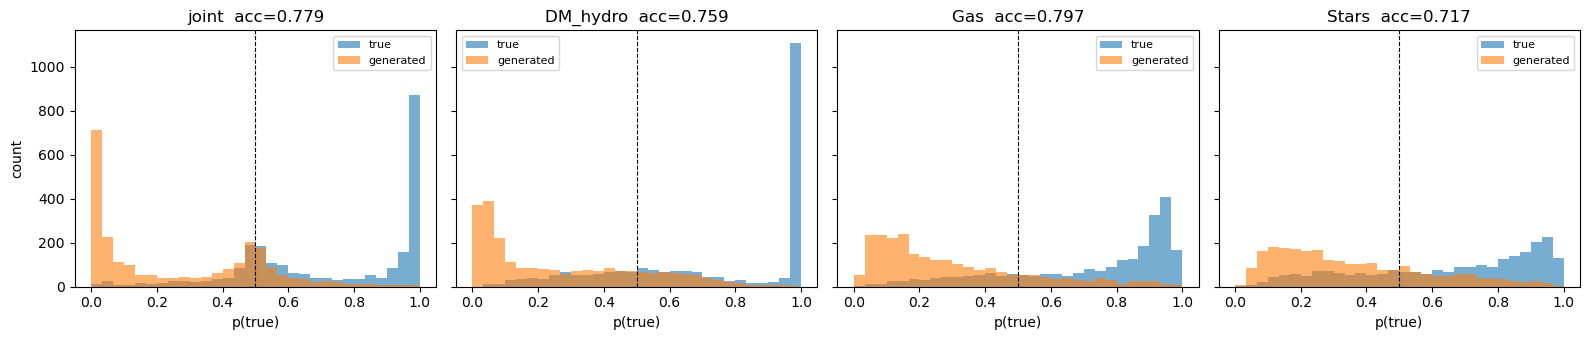

In [16]:
# --- diagnostic: probability histograms (true vs generated) per setup ---
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5), sharey=True)
for ax, r in zip(axes, results):
    p_true = r['probs'][r['ys'] == 1]
    p_gen  = r['probs'][r['ys'] == 0]
    ax.hist(p_true, bins=30, alpha=0.6, label='true', range=(0, 1))
    ax.hist(p_gen,  bins=30, alpha=0.6, label='generated', range=(0, 1))
    ax.axvline(0.5, color='k', ls='--', lw=0.8)
    ax.set_title(f'{r["tag"]}  acc={r["test_acc"]:.3f}')
    ax.set_xlabel('p(true)')
    ax.legend(fontsize=8)
axes[0].set_ylabel('count')
plt.tight_layout(); plt.show()

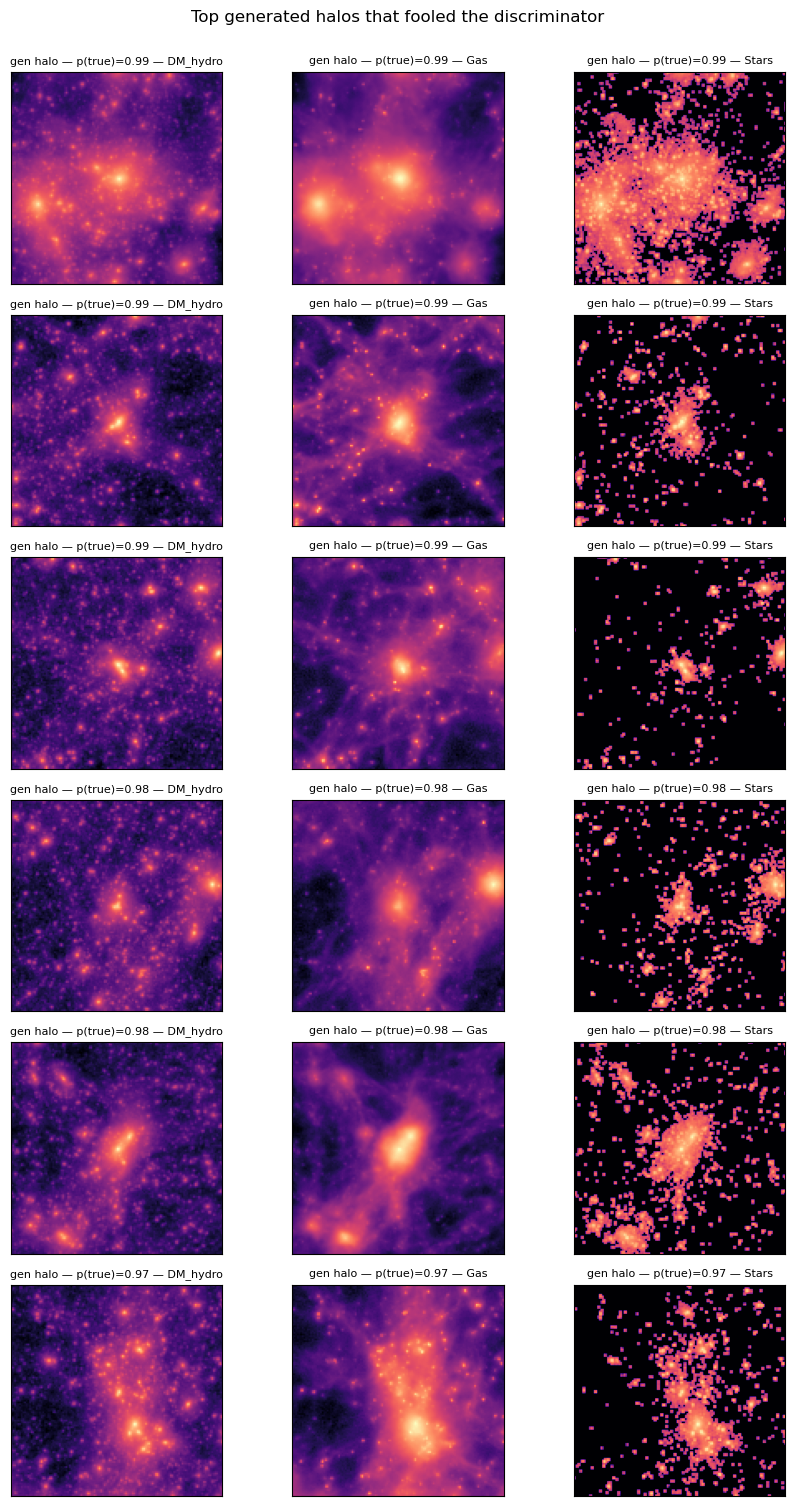

In [17]:
# --- showcase: which generated halos fooled the joint classifier most? ---
probs = joint_result['probs']; ys = joint_result['ys']
gen_idx = np.where(ys == 0)[0]
# rank generated halos by how strongly the classifier called them 'true'
rank = gen_idx[np.argsort(-probs[gen_idx])]
n_show = 6
# back out the original generated cutout index (test set ordering: true first, then gen)
n_true_test = X_te_true.shape[0]
gen_in_te = rank[:n_show] - n_true_test

fig, axes = plt.subplots(n_show, 3, figsize=(9, 2.5 * n_show))
for row, gi in enumerate(gen_in_te):
    for ch in range(3):
        axes[row, ch].imshow(X_te_gen[gi, ch], cmap='magma')
        axes[row, ch].set_title(f'gen halo — p(true)={probs[rank[row]]:.2f} — {CHANNEL_NAMES[ch]}', fontsize=8)
        axes[row, ch].set_xticks([]); axes[row, ch].set_yticks([])
plt.suptitle('Top generated halos that fooled the discriminator', y=1.001)
plt.tight_layout(); plt.show()

## Interpretation

- **test_acc ≈ 0.5**: the network can't distinguish generated from real — model wins.
- **test_acc ≈ 1.0**: discriminator wins; generated samples carry a systematic fingerprint.
- **fool_rate**: fraction of generated halos that scored as 'true'. >0.5 means most generated samples fooled the network.
- **Per-channel breakdown**: if Stars is the only channel above 0.6, the visible artifacts are in stars only.

Caveats: a small classifier is a weak adversary. A negative result (acc ≈ 0.5) means *this* network can't tell them apart, not that none can. Power-spectrum, profile, and bispectrum checks are complementary.

## Diagnostics: why can the discriminator tell them apart?

Four complementary views:
1. **Mean images** — systematic spatial offset between true and generated.
2. **Pixel histograms** — global brightness / dynamic-range biases per channel.
3. **Radial power spectra** — scale-dependent power differences (blurring, ringing, etc.).
4. **Gradient saliency** — which pixels / channels the joint classifier actually uses.

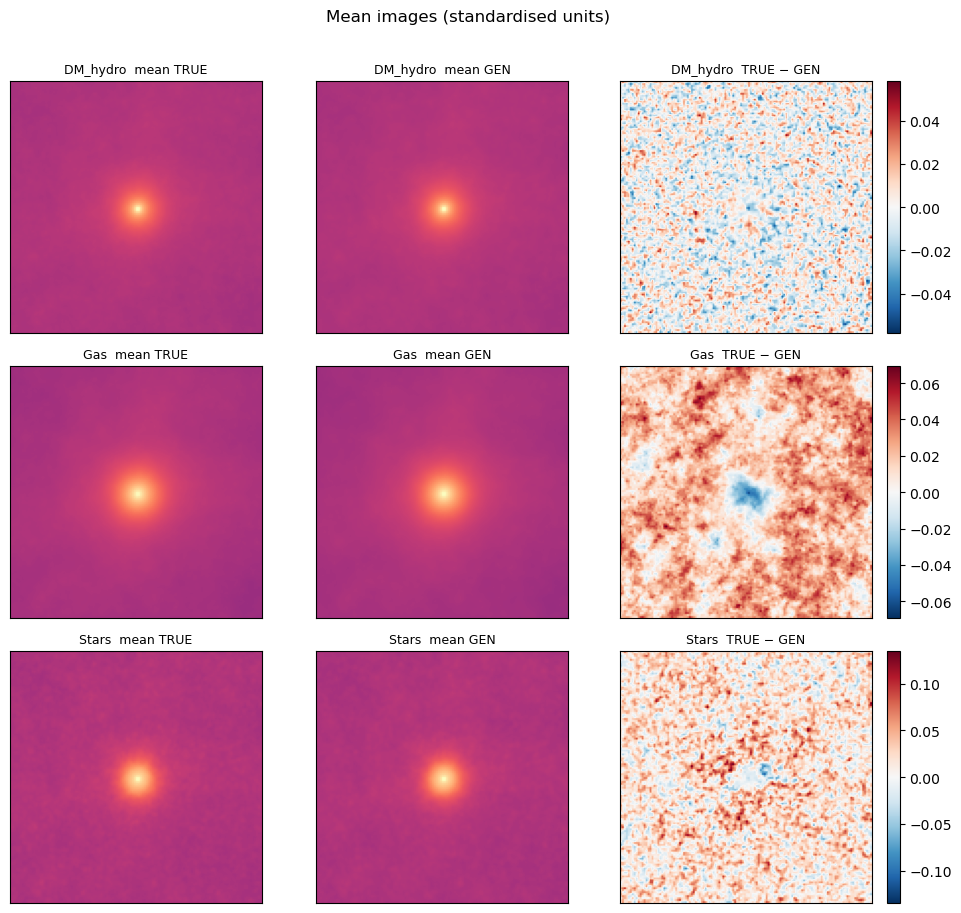

In [18]:
# --- 1. Mean images per channel (true vs generated, difference) ---
mean_true = X_te_true.mean(axis=0)  # (3, H, W)
mean_gen  = X_te_gen.mean(axis=0)
diff      = mean_true - mean_gen

fig, axes = plt.subplots(3, 3, figsize=(10, 9))
for ch, name in enumerate(CHANNEL_NAMES):
    vmax_m = max(np.abs(mean_true[ch]).max(), np.abs(mean_gen[ch]).max())
    vmax_d = np.abs(diff[ch]).max()
    axes[ch, 0].imshow(mean_true[ch], cmap='magma', vmin=-vmax_m, vmax=vmax_m)
    axes[ch, 0].set_title(f'{name}  mean TRUE',    fontsize=9)
    axes[ch, 1].imshow(mean_gen[ch],  cmap='magma', vmin=-vmax_m, vmax=vmax_m)
    axes[ch, 1].set_title(f'{name}  mean GEN',     fontsize=9)
    im = axes[ch, 2].imshow(diff[ch], cmap='RdBu_r', vmin=-vmax_d, vmax=vmax_d)
    axes[ch, 2].set_title(f'{name}  TRUE − GEN',  fontsize=9)
    plt.colorbar(im, ax=axes[ch, 2], fraction=0.046)
    for ax in axes[ch]: ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('Mean images (standardised units)', y=1.01)
plt.tight_layout(); plt.show()

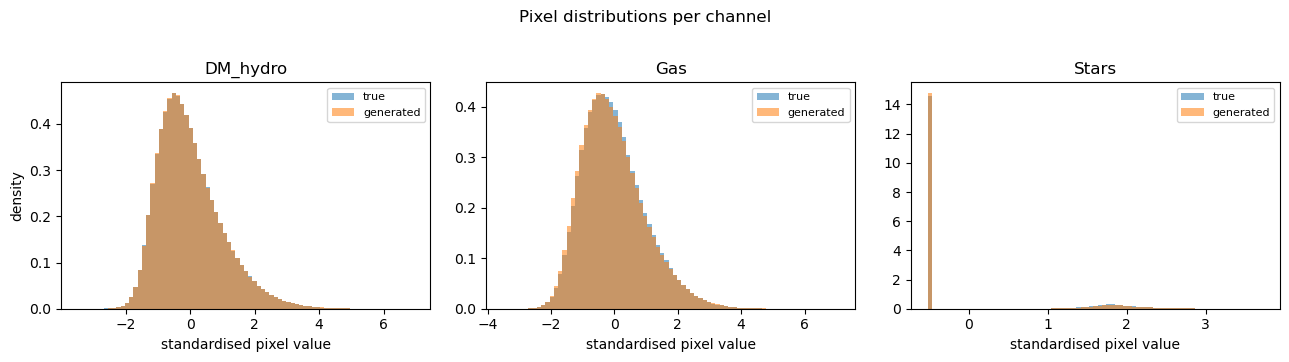

In [19]:
# --- 2. Pixel-value histograms per channel ---
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ch, name in enumerate(CHANNEL_NAMES):
    vals_t = X_te_true[:, ch].ravel()
    vals_g = X_te_gen [:, ch].ravel()
    lo = min(vals_t.min(), vals_g.min())
    hi = max(vals_t.max(), vals_g.max())
    bins = np.linspace(lo, hi, 80)
    axes[ch].hist(vals_t, bins=bins, alpha=0.55, density=True, label='true')
    axes[ch].hist(vals_g, bins=bins, alpha=0.55, density=True, label='generated')
    axes[ch].set_title(name); axes[ch].set_xlabel('standardised pixel value')
    axes[ch].legend(fontsize=8)
axes[0].set_ylabel('density')
plt.suptitle('Pixel distributions per channel', y=1.02)
plt.tight_layout(); plt.show()

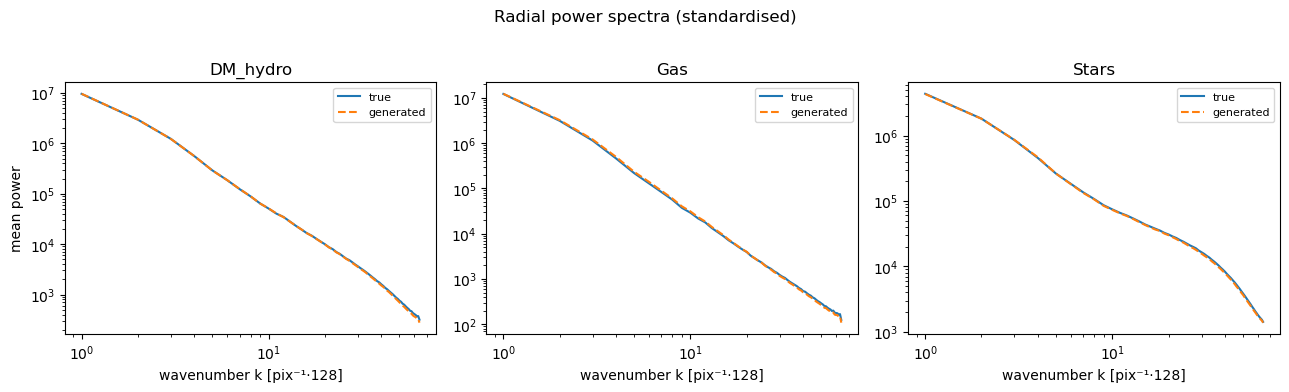

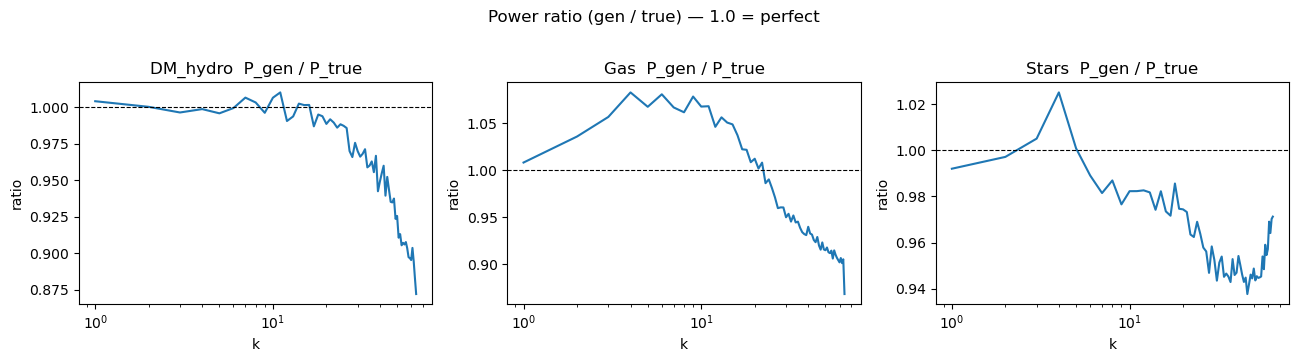

In [20]:
# --- 3. Radial power spectra per channel ---
def radial_power_spectrum(arr):
    """arr: (N, H, W). Returns (k_centers, mean_Pk) averaged over halos."""
    N, H, W = arr.shape
    fft2  = np.fft.fft2(arr, axes=(-2, -1))
    power = (np.abs(fft2) ** 2).mean(axis=0)  # (H, W) mean over halos
    kx = np.fft.fftfreq(W) * W
    ky = np.fft.fftfreq(H) * H
    KX, KY = np.meshgrid(kx, ky)
    K = np.sqrt(KX**2 + KY**2)
    k_max   = H // 2
    k_edges = np.arange(0.5, k_max + 1.5, 1.0)
    k_centers = 0.5 * (k_edges[:-1] + k_edges[1:])
    pk = np.array([power[(K >= k0) & (K < k1)].mean()
                   for k0, k1 in zip(k_edges[:-1], k_edges[1:])])
    return k_centers, pk

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ch, name in enumerate(CHANNEL_NAMES):
    k, pk_t = radial_power_spectrum(X_te_true[:, ch])
    _, pk_g = radial_power_spectrum(X_te_gen [:, ch])
    axes[ch].loglog(k, pk_t, label='true')
    axes[ch].loglog(k, pk_g, label='generated', ls='--')
    axes[ch].set_title(name); axes[ch].set_xlabel('wavenumber k [pix⁻¹·128]')
    axes[ch].legend(fontsize=8)
axes[0].set_ylabel('mean power')
plt.suptitle('Radial power spectra (standardised)', y=1.02)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ch, name in enumerate(CHANNEL_NAMES):
    k, pk_t = radial_power_spectrum(X_te_true[:, ch])
    _, pk_g = radial_power_spectrum(X_te_gen [:, ch])
    ratio = pk_g / np.where(pk_t > 0, pk_t, np.nan)
    axes[ch].semilogx(k, ratio); axes[ch].axhline(1, color='k', lw=0.8, ls='--')
    axes[ch].set_title(f'{name}  P_gen / P_true'); axes[ch].set_xlabel('k')
    axes[ch].set_ylabel('ratio')
plt.suptitle('Power ratio (gen / true) — 1.0 = perfect', y=1.02)
plt.tight_layout(); plt.show()

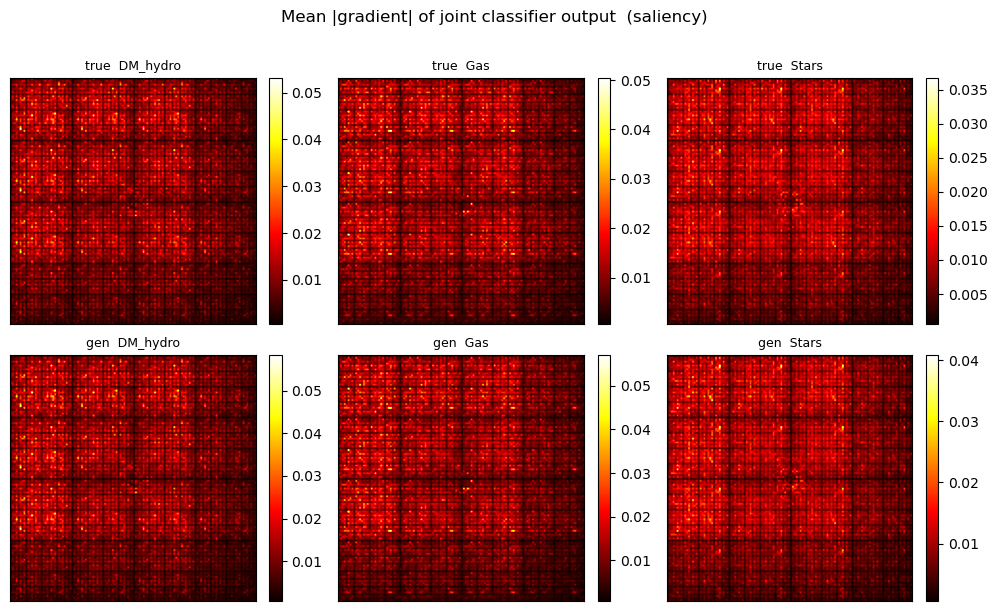

Channel saliency sums (higher = more weight):
  true: DM_hydro=0.355   Gas=0.359   Stars=0.286
  gen: DM_hydro=0.354   Gas=0.360   Stars=0.286


In [21]:
# --- 4. Gradient saliency maps from the joint classifier ---
# Which pixels/channels drive the true/generated classification?
def compute_mean_saliency(model, X_true, X_gen, n=300):
    """Average |d logit / d input| over n randomly-drawn halos per class."""
    model.eval()
    idx_t = np.random.choice(len(X_true), min(n, len(X_true)), replace=False)
    idx_g = np.random.choice(len(X_gen),  min(n, len(X_gen)),  replace=False)
    results = {}
    for label, X, idx in [('true', X_true, idx_t), ('gen', X_gen, idx_g)]:
        xt = torch.tensor(X[idx], dtype=torch.float32, device=DEVICE, requires_grad=True)
        logits = model(xt)
        logits.sum().backward()
        sal = xt.grad.detach().abs().cpu().numpy()  # (n, 3, H, W)
        results[label] = sal.mean(axis=0)           # (3, H, W)
    return results

sal = compute_mean_saliency(joint_model, X_te_true, X_te_gen, n=400)

fig, axes = plt.subplots(2, 3, figsize=(10, 6))
for row, label in enumerate(['true', 'gen']):
    for ch, name in enumerate(CHANNEL_NAMES):
        s = sal[label][ch]
        im = axes[row, ch].imshow(s, cmap='hot')
        axes[row, ch].set_title(f'{label}  {name}', fontsize=9)
        axes[row, ch].set_xticks([]); axes[row, ch].set_yticks([])
        plt.colorbar(im, ax=axes[row, ch], fraction=0.046)
plt.suptitle('Mean |gradient| of joint classifier output  (saliency)', y=1.01)
plt.tight_layout(); plt.show()

# per-channel saliency totals: which channel dominates?
print('Channel saliency sums (higher = more weight):')
for label in ['true', 'gen']:
    totals = sal[label].sum(axis=(-2, -1))
    totals /= totals.sum()
    print(f'  {label}: ' + '   '.join(f'{n}={v:.3f}' for n, v in zip(CHANNEL_NAMES, totals)))